!/usr/bin/env python
coding: utf-8


In [2]:
from google.colab import files
uploaded=files.upload()

Saving heart.csv to heart.csv


In [4]:
import pandas as pd
import numpy as np

df=pd.read_csv("heart.csv")
df

,age,sex,cp,trtbps,chol,fbs,restecg,thalachh,exng,oldpeak,slp,caa,thall,output
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
298,57,0,0,140,241,0,1,123,1,0.2,1,0,3,0
299,45,1,3,110,264,0,1,132,0,1.2,1,0,3,0
300,68,1,0,144,193,1,1,141,0,3.4,1,2,3,0
301,57,1,0,130,131,0,1,115,1,1.2,1,1,3,0


None (0): 138
One (1): 165


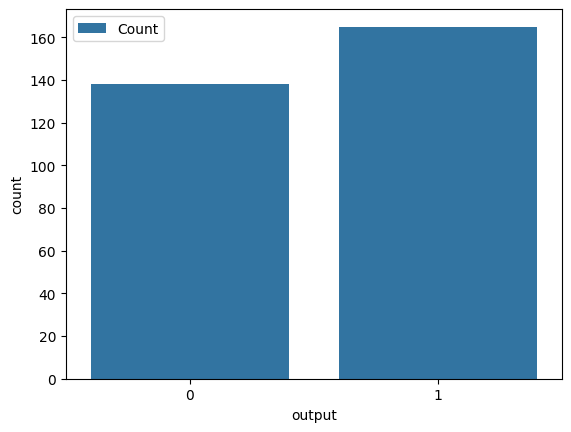

In [5]:
import seaborn as sns
import matplotlib.pyplot as plt


ax = sns.countplot(x='output', data=df, order=[0, 1], label='Count')

# Get the value counts of the 'output' column
value_counts = df['output'].value_counts()

# Print the value counts with custom labels
print(f'None (0): {value_counts.get(0, 0)}')
print(f'One (1): {value_counts.get(1, 0)}')

In [7]:
# Display the plot
plt.show()

In [8]:
#len() means length of any items
len(df.columns)

14

In [9]:

# All columns except the last one
X = df.iloc[:, :-1].values
# last column
y = df.iloc[:, -1].values

In [10]:
X

array([[63.,  1.,  3., ...,  0.,  0.,  1.],
       [37.,  1.,  2., ...,  0.,  0.,  2.],
       [41.,  0.,  1., ...,  2.,  0.,  2.],
       ...,
       [68.,  1.,  0., ...,  1.,  2.,  3.],
       [57.,  1.,  0., ...,  1.,  1.,  3.],
       [57.,  0.,  1., ...,  1.,  1.,  2.]])

In [11]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


X_train.shape

(242, 13)

In [12]:
from sklearn.preprocessing import MinMaxScaler

sc= MinMaxScaler()
X_train = sc.fit_transform(X_train)
X_test = sc.transform(X_test)


X_train

array([[0.27083333, 1.        , 0.33333333, ..., 1.        , 0.        ,
        0.66666667],
       [0.60416667, 1.        , 0.        , ..., 1.        , 0.        ,
        1.        ],
       [0.35416667, 1.        , 0.66666667, ..., 0.5       , 0.        ,
        0.66666667],
       ...,
       [0.83333333, 1.        , 1.        , ..., 0.5       , 0.25      ,
        0.66666667],
       [0.35416667, 1.        , 0.        , ..., 1.        , 0.        ,
        1.        ],
       [0.70833333, 0.        , 0.33333333, ..., 1.        , 0.5       ,
        0.66666667]])

In [13]:
y_train

array([1, 0, 0, 1, 0, 1, 1, 1, 0, 1, 1, 0, 1, 0, 1, 0, 0, 0, 1, 1, 0, 1,
       1, 1, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 0, 0,
       1, 1, 1, 1, 0, 1, 0, 0, 1, 0, 1, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 1,
       0, 0, 0, 1, 1, 0, 0, 1, 1, 0, 1, 0, 0, 0, 0, 0, 1, 1, 1, 0, 1, 0,
       0, 1, 1, 1, 1, 0, 1, 1, 0, 1, 0, 0, 1, 0, 1, 0, 1, 1, 1, 1, 1, 0,
       1, 0, 1, 1, 0, 0, 1, 1, 0, 1, 1, 0, 1, 0, 1, 0, 0, 1, 0, 1, 0, 1,
       1, 1, 1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 1, 1, 1, 0, 1, 0, 0, 1, 1, 1,
       1, 0, 1, 1, 0, 1, 1, 0, 1, 1, 1, 0, 0, 1, 1, 0, 1, 1, 0, 0, 1, 0,
       0, 0, 0, 1, 1, 1, 0, 0, 0, 0, 1, 1, 0, 1, 0, 0, 0, 1, 1, 1, 1, 1,
       1, 0, 1, 1, 1, 0, 0, 1, 1, 0, 0, 1, 0, 0, 1, 1, 0, 0, 0, 0, 0, 1,
       1, 0, 0, 1, 1, 0, 0, 0, 1, 1, 1, 1, 1, 0, 1, 0, 1, 0, 1, 1, 0, 1])

In [16]:
from tensorflow import keras

from keras.models import Sequential
from keras.layers import Dense
from keras import layers

ann_model = Sequential([
    Dense(64, activation='relu', input_shape=(13,)),  # Adjust input_shape to (13,)
    Dense(64, activation='relu'),
    Dense(1, activation='sigmoid')
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [17]:
ann_model.compile(optimizer = 'adam', loss = 'binary_crossentropy', metrics = ['accuracy'])


ann_model.fit(X_train, y_train, batch_size = 5, epochs = 10)

y_pred = ann_model.predict(X_test)
y_pred = (y_pred > 0.5)

y_pred

Epoch 1/10
49/49 ━━━━━━━━━━━━━━━━━━━━ 6s 12ms/step - accuracy: 0.6322 - loss: 0.6580
Epoch 2/10
49/49 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.7975 - loss: 0.5164
Epoch 3/10
49/49 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - accuracy: 0.8140 - loss: 0.4310
Epoch 4/10
49/49 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.8223 - loss: 0.3892
Epoch 5/10
49/49 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.8388 - loss: 0.3760
Epoch 6/10
49/49 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.8471 - loss: 0.3618
Epoch 7/10
49/49 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.8512 - loss: 0.3609
Epoch 8/10
49/49 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.8471 - loss: 0.3426
Epoch 9/10
49/49 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.8430 - loss: 0.3446
Epoch 10/10
49/49 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.8719 - loss: 0.3374
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 271ms/step


array([[False],
       [ True],
       [ True],
       [False],
       [ True],
       [ True],
       [False],
       [False],
       [False],
       [False],
       [ True],
       [False],
       [ True],
       [False],
       [ True],
       [ True],
       [ True],
       [False],
       [False],
       [False],
       [ True],
       [False],
       [False],
       [ True],
       [ True],
       [ True],
       [ True],
       [False],
       [False],
       [ True],
       [False],
       [False],
       [False],
       [False],
       [ True],
       [False],
       [ True],
       [ True],
       [ True],
       [ True],
       [False],
       [ True],
       [ True],
       [ True],
       [ True],
       [False],
       [False],
       [ True],
       [False],
       [False],
       [False],
       [False],
       [ True],
       [ True],
       [False],
       [False],
       [False],
       [ True],
       [False],
       [False],
       [False]])

In [18]:
from sklearn.metrics import accuracy_score
ann_accuracy=accuracy_score(y_test,y_pred)
ann_accuracy

0.8360655737704918

In [20]:
from sklearn.metrics import f1_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score

In [29]:

print('ANN accuracy:', ann_accuracy*100)


ann_f1=f1_score(y_test,y_pred)
ann_f1
print('ANN F1:', ann_f1*100)


ann_precision=precision_score(y_test,y_pred)
ann_precision
print('ANN Precision:', ann_precision*100)


ann_recall=recall_score(y_test,y_pred)
ann_recall
print('ANN Recall:', ann_recall*100)

ANN accuracy: 83.60655737704919
ANN F1: 83.33333333333334
ANN Precision: 89.28571428571429
ANN Recall: 78.125


In [30]:
#knn

from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier(n_neighbors=1)
knn.fit(X_train, y_train)
y_pred = knn.predict(X_test)

In [31]:
knn_accuracy = accuracy_score(y_test, knn.predict(X_test))
print("Accuracy:", knn_accuracy)
print('KNN Accuracy:', knn_accuracy*100)


knn_f1=f1_score(y_test,y_pred)
knn_f1
print('KNN F1:', knn_f1*100)


# In[46]:


knn_precision=precision_score(y_test,y_pred)
knn_precision
print('KNN Precision:', knn_precision*100)


# In[47]:


knn_recall=recall_score(y_test,y_pred)
knn_recall
print('KNN Recall:', knn_recall*100)

Accuracy: 0.8032786885245902
KNN Accuracy: 80.32786885245902
KNN F1: 79.3103448275862
KNN Precision: 88.46153846153845
KNN Recall: 71.875


In [32]:
#svm

from sklearn.svm import SVC

svm = SVC(kernel='sigmoid')

svm.fit(X_train, y_train)
y_pred = svm.predict(X_test)


In [33]:
svm_accuracy = accuracy_score(y_test, y_pred)
print("Accuracy of SVM:", svm_accuracy)
print('SVM Accuracy:' , svm_accuracy*100)

svm_f1=f1_score(y_test,y_pred)
svm_f1
print('SVM:', svm_f1*100)

svm_precision=precision_score(y_test,y_pred)
svm_precision
print('SVM Precision:', svm_precision*100)

svm_recall=recall_score(y_test,y_pred)
svm_recall
print('SVM Recall:', svm_recall*100)

Accuracy of SVM: 0.7704918032786885
SVM Accuracy: 77.04918032786885
SVM: 78.125
SVM Precision: 78.125
SVM Recall: 78.125


In [63]:
#cnn

X_train.shape


X_train_reshaped = X_train.reshape(X_train.shape[0], X_train.shape[1], 1)
X_test_reshaped = X_test.reshape(X_test.shape[0], X_test.shape[1], 1)


X_train_reshaped.shape


from keras.layers import Conv1D, MaxPooling1D, Flatten, Dense

cnn_model = Sequential()
cnn_model.add(Conv1D(filters=64, kernel_size=3, activation='relu', input_shape=(X_train_reshaped.shape[1], 1)))
cnn_model.add(MaxPooling1D(pool_size=1))
cnn_model.add(Flatten())
cnn_model.add(Dense(10, activation='relu'))
cnn_model.add(Dense(1, activation='sigmoid'))


cnn_model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

cnn_model.fit(X_train_reshaped, y_train, epochs=30, batch_size=32, validation_data=(X_test_reshaped, y_test))


Epoch 1/30


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


8/8 ━━━━━━━━━━━━━━━━━━━━ 2s 58ms/step - accuracy: 0.7025 - loss: 0.6768 - val_accuracy: 0.8197 - val_loss: 0.6530
Epoch 2/30
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.7727 - loss: 0.6418 - val_accuracy: 0.8361 - val_loss: 0.6156
Epoch 3/30
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 0.7851 - loss: 0.6049 - val_accuracy: 0.8197 - val_loss: 0.5742
Epoch 4/30
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.7893 - loss: 0.5634 - val_accuracy: 0.8197 - val_loss: 0.5319
Epoch 5/30
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.7851 - loss: 0.5215 - val_accuracy: 0.8197 - val_loss: 0.4871
Epoch 6/30
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.7975 - loss: 0.4837 - val_accuracy: 0.8361 - val_loss: 0.4536
Epoch 7/30
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.8017 - loss: 0.4544 - val_accuracy: 0.8361 - val_loss: 0.4339
Epoch 8/30
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.7810 - loss: 0.4356 - val_accuracy: 0.8033 - val_loss: 0.4251
Epoch 9/30


In [64]:

# Generate predictions for the CNN model
y_pred_cnn = cnn_model.predict(X_test_reshaped)
y_pred_cnn = (y_pred_cnn > 0.5)


cnn_f1=f1_score(y_test,y_pred_cnn)
cnn_f1
print('CNN F1:', cnn_f1*100)


cnn_recall=recall_score(y_test,y_pred_cnn)
cnn_recall
print('CNN Recall:', cnn_recall*100)


cnn_precision=precision_score(y_test,y_pred_cnn)
cnn_precision
print('CNN Precision:', cnn_precision*100)

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 110ms/step
CNN F1: 81.35593220338984
CNN Recall: 75.0
CNN Precision: 88.88888888888889


In [65]:
cnn_accuracy


0.7704918032786885

In [51]:
#dtc
from sklearn.tree import DecisionTreeClassifier

dtc = DecisionTreeClassifier()

dtc = dtc.fit(X_train,y_train)
y_pred = dtc.predict(X_test)


In [50]:
dtc_accuracy = accuracy_score(y_test, y_pred)
print("Accuracy of dtc:", dtc_accuracy)
print('DTC Accuracy:', dtc_accuracy*100)

dtc_f1=f1_score(y_test,y_pred)
dtc_f1
print('DTC F1:', dtc_f1*100)

dtc_precision=precision_score(y_test,y_pred)
ann_precision
print('DTC Precision:', dtc_precision*100)

dtc_recall=recall_score(y_test,y_pred)
dtc_recall
print('DTC Recall:', dtc_recall*100)

Accuracy of dtc: 0.7868852459016393
DTC Accuracy: 78.68852459016394
DTC F1: 77.19298245614034
DTC Precision: 88.0
DTC Recall: 68.75


In [52]:
#random forest

from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier()

rf.fit(X_train, y_train)
y_pred = rf.predict(X_test)


In [53]:
rf_accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", rf_accuracy)
print('RF Accuracy:', rf_accuracy*100)

rf_f1=f1_score(y_test,y_pred)
rf_f1
print('RF Recall:', rf_f1*100)


rf_precision=precision_score(y_test,y_pred)
rf_precision
print('RF Precision:', rf_precision*100)


rf_recall=recall_score(y_test,y_pred)
rf_recall
print('RF Recall:', rf_recall*100)

Accuracy: 0.8360655737704918
RF Accuracy: 83.60655737704919
RF Recall: 84.375
RF Precision: 84.375
RF Recall: 84.375


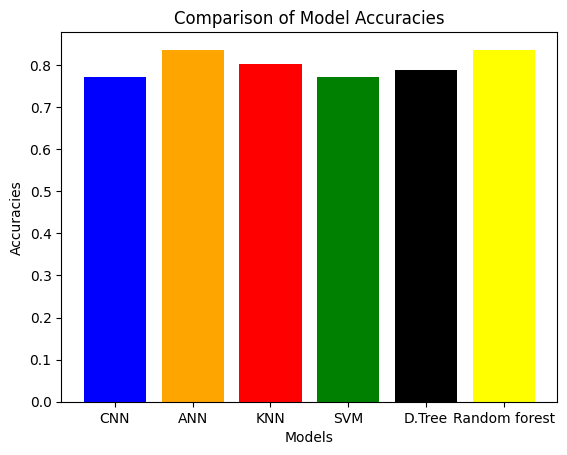

In [69]:
from sklearn.metrics import accuracy_score

plt.bar(['CNN', 'ANN', 'KNN', 'SVM', 'D.Tree', 'Random forest'], [cnn_accuracy, ann_accuracy, knn_accuracy, svm_accuracy, dtc_accuracy, rf_accuracy], color=['blue', 'orange', 'red', 'green', 'black', 'yellow'])
plt.xlabel('Models')
plt.ylabel('Accuracies')
plt.title('Comparison of Model Accuracies')
plt.show()

In [66]:
import shap
shap.initjs()

In [75]:
shapexplainable1 = shap.Explainer(rf, X_train)
shap_values = shapexplainable1.shap_values(X_test, check_additivity=False)

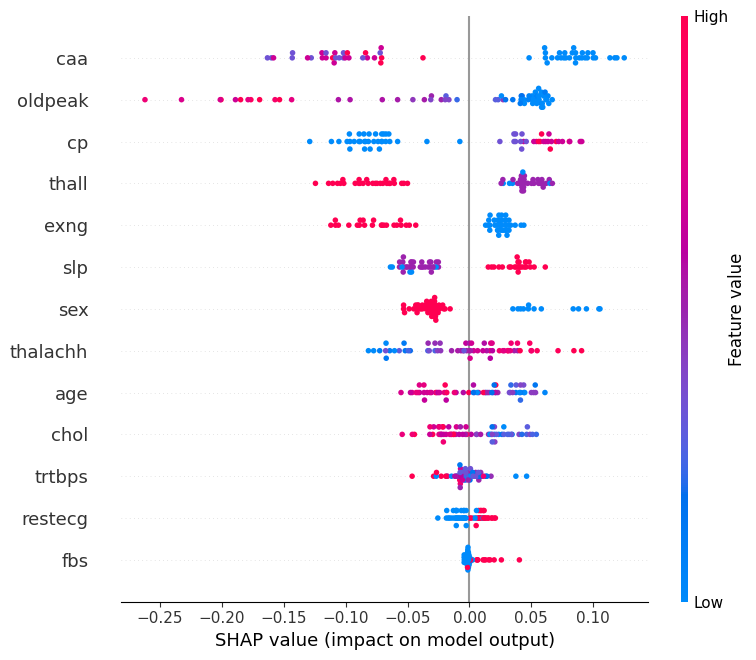

In [85]:
#summary plot
shap.summary_plot(shap_values[:, :, 1], X_test, feature_names=df.columns[:-1])

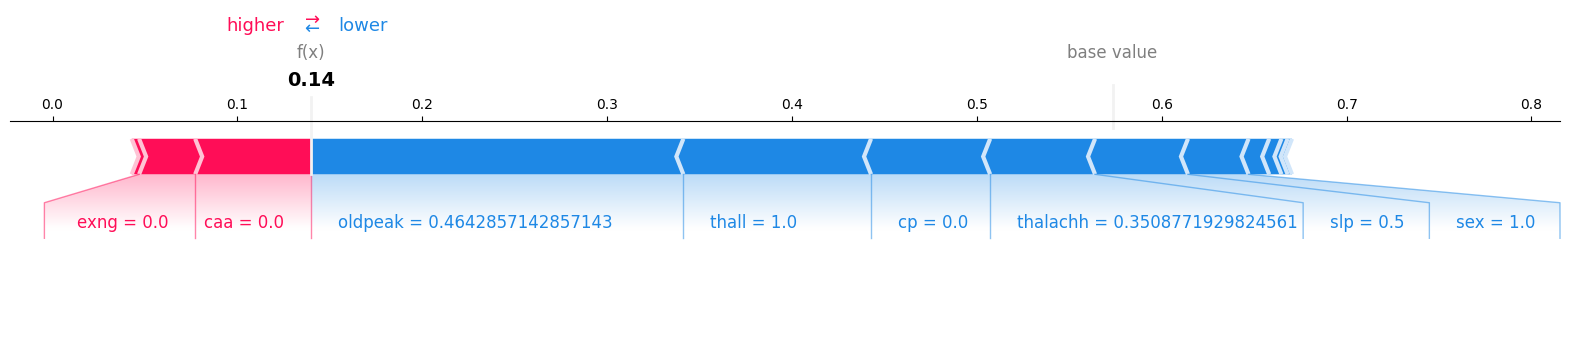

In [102]:
shap.force_plot(shapexplainable1.expected_value[1],
    shap_values[-1, :, 1], features=X_test[-1, :],
    feature_names=df.columns[:-1],
    matplotlib=True, show=False, plot_cmap=['#77dd77', '#f99191'])